In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summary_data = [
    ["Independent", "-", False, None, 4.0998, 2.8418, 17.1460],
    ["Position", "gamma=0.2", False, None, 2.2140, 1.5347, 4.6397],
    ["Position", "gamma=0.2", True, None, 3.3498, 2.3219, 10.1948],
    ["MovingSigmoid", "k=0.5", False, False, 7.2994, 5.0595, 157.5182],
    ["MovingSigmoid", "k=0.5", False, True, 6.0158, 4.1699, 64.7064],
    ["MovingSigmoid", "k=1", False, True, 3.3428, 2.3171, 10.1457],
    ["MovingSigmoid", "k=2", False, True, 3.3736, 2.3384, 10.3649],
    ["MovingSigmoid", "k=5", False, True, 2.4781, 1.7177, 5.5715],
]

summary = pd.DataFrame(
    summary_data,
    columns=[
        "Schedule",
        "Parameter",
        "PositionWeighting",
        "Calibrated",
        "Final_BPD",
        "Final_NLL",
        "Final_PPL",
    ],
)

summary["Run"] = summary.apply(
    lambda r: (
        r["Schedule"]
        + (" " + r["Parameter"] if r["Parameter"] != "-" else "")
        + (" weighted" if r["PositionWeighting"] else "")
        + (" calibrated" if r["Calibrated"] is True else "")
        + (" uncalibrated" if r["Calibrated"] is False and r["Schedule"] == "MovingSigmoid" else "")
    ),
    axis=1,
)

summary

,Schedule,Parameter,PositionWeighting,Calibrated,Final_BPD,Final_NLL,Final_PPL,Run
0,Independent,-,False,None,4.0998,2.8418,17.1460,Independent
1,Position,gamma=0.2,False,None,2.2140,1.5347,4.6397,Position gamma=0.2
2,Position,gamma=0.2,True,None,3.3498,2.3219,10.1948,Position gamma=0.2 weighted
3,MovingSigmoid,k=0.5,False,False,7.2994,5.0595,157.5182,MovingSigmoid k=0.5 uncalibrated
4,MovingSigmoid,k=0.5,False,True,6.0158,4.1699,64.7064,MovingSigmoid k=0.5 calibrated
5,MovingSigmoid,k=1,False,True,3.3428,2.3171,10.1457,MovingSigmoid k=1 calibrated
6,MovingSigmoid,k=2,False,True,3.3736,2.3384,10.3649,MovingSigmoid k=2 calibrated
7,MovingSigmoid,k=5,False,True,2.4781,1.7177,5.5715,MovingSigmoid k=5 calibrated


In [ ]:
curves_data = {
    "Epoch": list(range(20)),
    "Independent": [
        4.4278, 4.3499, 4.3031, 3.2597, 4.1314,
        3.8618, 3.7175, 4.0032, 3.0106, 3.6313,
        2.9676, 2.8962, 3.3012, 2.4557, 2.8766,
        3.1485, 3.2728, 3.5306, 2.9045, 2.8418,
    ],
    "Position gamma=0.2": [
        5.1138, 4.7193, 4.8074, 3.9798, 3.5245,
        3.5134, 3.6063, 3.5355, 2.6296, 3.1716,
        3.8082, 2.7027, 2.2683, 3.6053, 2.1474,
        2.7187, 3.2572, 2.5367, 2.4920, 1.5347,
    ],
    "Position gamma=0.2 weighted": [
        4.7447, 4.4624, 5.0752, 4.2550, 4.0446,
        3.9485, 3.6063, 3.5355, 2.6296, 2.9747,
        3.3129, 2.7027, 2.2683, 3.2581, 2.1474,
        2.2862, 3.2572, 2.5367, 3.0130, 2.3219,
    ],
    "Sigmoid k=0.5 uncalibrated": [
        7.8911, 13.1959, 16.0856, 24.6117, 4.7964,
        26.2234, 3.4156, 3.8431, 3.8280, 4.4839,
        17.7679, 5.0241, 5.6094, 4.9166, 3.4259,
        2.2862, 3.7370, 2.5561, 4.1349, 5.0595,
    ],
    "Sigmoid k=0.5 calibrated": [
        5.0095, 13.1262, 5.2274, 5.9883, 8.0617,
        5.7534, 5.0879, 3.3917, 3.1941, 2.4187,
        3.6087, 3.8204, 4.0831, 2.9183, 2.7872,
        2.3491, 1.9756, 2.9524, 3.2636, 4.1699,
    ],
    "Sigmoid k=1 calibrated": [
        7.9993, 4.5815, 4.6426, 17.8933, 3.9536,
        3.4158, 3.9066, 2.5040, 3.8435, 8.3829,
        3.4043, 3.9178, 2.4455, 3.6635, 2.4912,
        3.2295, 2.1006, 2.8499, 2.2539, 2.3171,
    ],
    "Sigmoid k=2 calibrated": [
        4.0830, 11.7962, 4.0613, 3.8611, 3.2266,
        3.6516, 3.1171, 2.8273, 2.7952, 2.2986,
        3.5549, 2.3095, 1.9726, 2.3653, 3.0404,
        2.2348, 2.3887, 1.1203, 1.7051, 2.3384,
    ],
    "Sigmoid k=5 calibrated": [
        2.6105, 2.7550, 3.2393, 2.6802, 2.4211,
        3.0869, 2.3225, 2.5788, 2.3348, 2.0946,
        2.5702, 1.6467, 1.1706, 1.7175, 1.7186,
        1.7419, 2.4311, 1.8595, 1.8309, 1.7177,
    ],
}

curves = pd.DataFrame(curves_data)
curves

,Epoch,Independent,Position gamma=0.2,Position gamma=0.2 weighted,Sigmoid k=0.5 uncalibrated,Sigmoid k=0.5 calibrated,Sigmoid k=1 calibrated,Sigmoid k=2 calibrated,Sigmoid k=5 calibrated
0,0,4.4278,5.1138,4.7447,7.8911,5.0095,7.9993,4.0830,2.6105
1,1,4.3499,4.7193,4.4624,13.1959,13.1262,4.5815,11.7962,2.7550
2,2,4.3031,4.8074,5.0752,16.0856,5.2274,4.6426,4.0613,3.2393
3,3,3.2597,3.9798,4.2550,24.6117,5.9883,17.8933,3.8611,2.6802
4,4,4.1314,3.5245,4.0446,4.7964,8.0617,3.9536,3.2266,2.4211
5,5,3.8618,3.5134,3.9485,26.2234,5.7534,3.4158,3.6516,3.0869
6,6,3.7175,3.6063,3.6063,3.4156,5.0879,3.9066,3.1171,2.3225
7,7,4.0032,3.5355,3.5355,3.8431,3.3917,2.5040,2.8273,2.5788
8,8,3.0106,2.6296,2.6296,3.8280,3.1941,3.8435,2.7952,2.3348
9,9,3.6313,3.1716,2.9747,4.4839,2.4187,8.3829,2.2986,2.0946


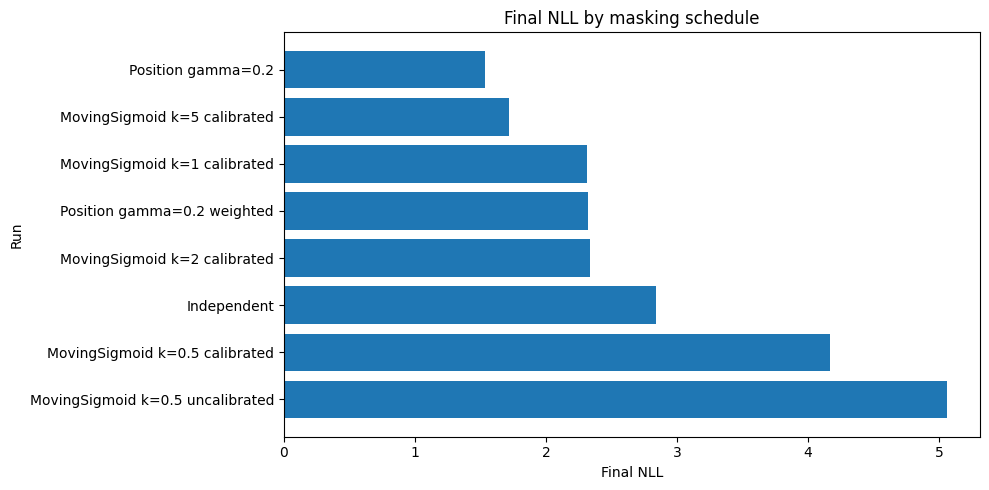

In [3]:
plot_df = summary.sort_values("Final_NLL", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["Run"], plot_df["Final_NLL"])
plt.xlabel("Final NLL")
plt.ylabel("Run")
plt.title("Final NLL by masking schedule")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

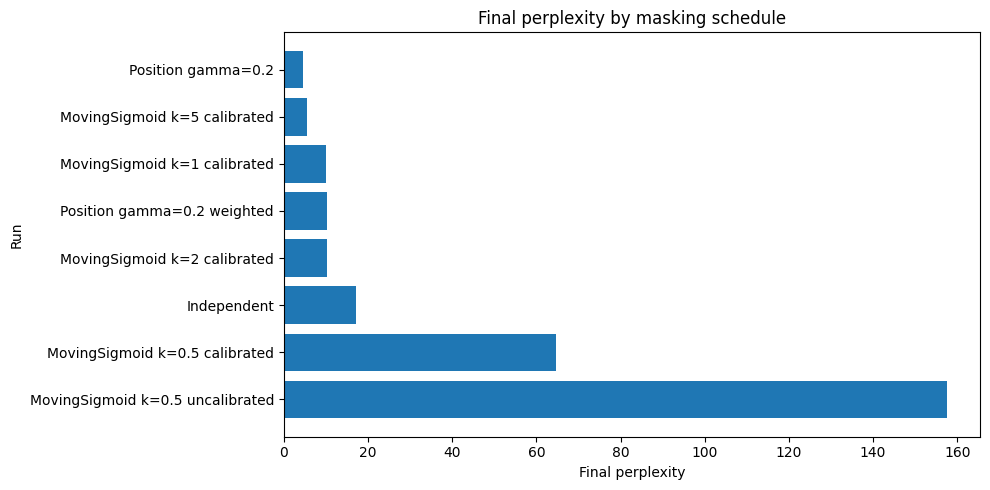

In [4]:
plot_df = summary.sort_values("Final_PPL", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["Run"], plot_df["Final_PPL"])
plt.xlabel("Final perplexity")
plt.ylabel("Run")
plt.title("Final perplexity by masking schedule")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

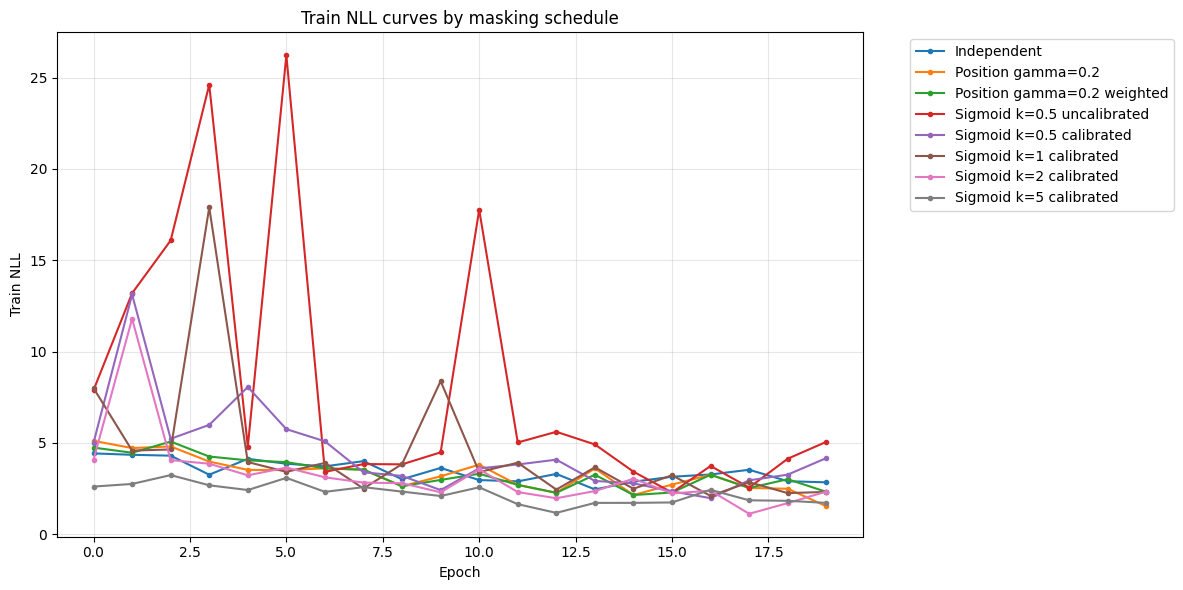

In [7]:
plt.figure(figsize=(12, 6))

for col in curves.columns:
    if col != "Epoch":
        plt.plot(curves["Epoch"], curves[col], marker=".", linewidth=1.5, label=col)

plt.xlabel("Epoch")
plt.ylabel("Train NLL")
plt.title("Train NLL curves by masking schedule")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

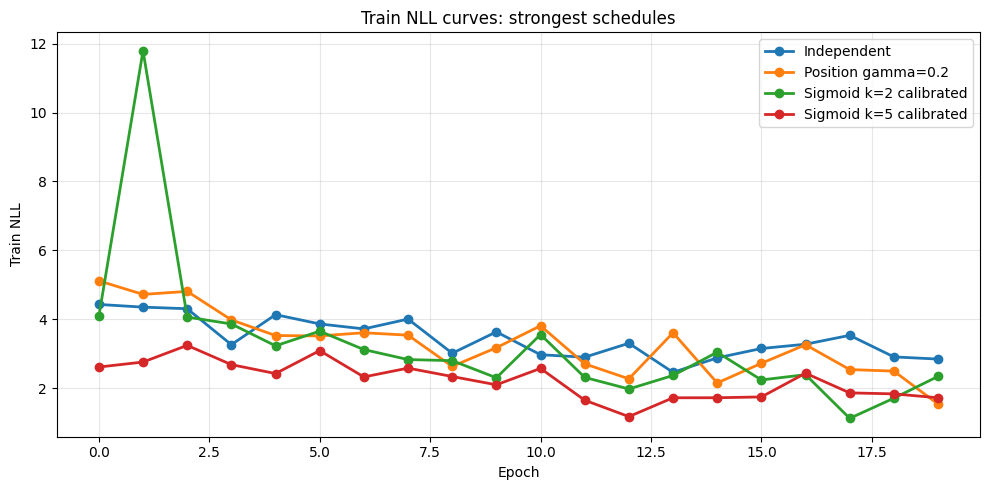

In [8]:
best_cols = [
    "Independent",
    "Position gamma=0.2",
    "Sigmoid k=2 calibrated",
    "Sigmoid k=5 calibrated",
]

plt.figure(figsize=(10, 5))

for col in best_cols:
    plt.plot(curves["Epoch"], curves[col], marker="o", linewidth=2, label=col)

plt.xlabel("Epoch")
plt.ylabel("Train NLL")
plt.title("Train NLL curves: strongest schedules")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()